In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.linalg as linalg
from src.pt import Tangent
import ot


In [2]:

class EmpiricalMeasure:
    def __init__(self, locs, weights):
        """Empirical measure class.

        Parameters
        ----------
        locs : np.ndarray
            Locations of the empirical measure.
        weights : np.ndarray
            Weights of the empirical measure.
        """
        self.locs = locs
        self.weights = weights


class Tangent:
    def __init__(self):
        """Base Tangent class.

        Parameters
        ----------
        A : np.ndarray
            Matrix component of the tangent vector.
        a : np.ndarray
            Vector component of the tangent vector.
        """
        pass

    def pushforward_measure(self, t):
        """Compute the pushforward mean and covariance at time t."""
        pass

    def interpolate(self):
        pass

    def parallel_transport(self):
        pass



class W2EuclideanTangent(Tangent):
    def __init__(self, locs_src, vels = None, coupling = None, locs_dst = None):
        """Tangent vector in the P_2(R^d) space.

        Parameters
        ----------
        vels : np.ndarray
            Velocities of the tangent vectors.
        locs : np.ndarray
            Locations of the tangent vectors.
        """
        super().__init__()
        # either (vels, locs_src), or (coupling, locs_src, locs_dst)
        if vels is not None and locs_src is not None:
            assert coupling is None and locs_dst is None, "If vels and locs_src are provided, coupling and locs_dst should be None."
        elif coupling is not None and locs_src is not None and locs_dst is not None:
            assert vels is None, "If coupling, locs_src and locs_dst are provided, vels should be None."
        else:
            raise ValueError("Either (vels, locs_src) or (coupling, locs_src, locs_dst) should be provided.")
        self.vels = vels
        self.locs_src = locs_src
        self.coupling = coupling
        self.locs_dst = locs_dst

    def pushforward_measure(self, t):
        """Compute the pushforward mean and covariance at time t."""
        # Compute the pushforward mean and covariance at time t
        pass

    def interpolate(self):
        pass

    def parallel_transport(self):
        pass


In [23]:

def interp_tan(tangent, t_0, t_1):
    # get the interpolated map along the geodesic described by tangent at time t_0 and t_1
    assert 0 <= t_0 <= 1 and 0 <= t_1 <= 1, "t_0 and t_1 should be in [0, 1]."
    if tangent.vels is not None and tangent.locs_src is not None:
        return interp_tan_vel(tangent, t_0, t_1)
    elif tangent.coupling is not None and tangent.locs_src is not None and tangent.locs_dst is not None:
        return interp_tan_coupling(tangent, t_0, t_1)

def interp_tan_vel(tangent, t_0, t_1):
    # construct the flow from time t_0 to t_1 along a constant velocity field
    locs_t0 = tangent.locs_src + t_0 * tangent.vels
    vels = (t_1 - t_0) * tangent.vels
    return W2EuclideanTangent(locs_src=locs_t0, vels=vels)

def project_tan(tangent: W2EuclideanTangent):
    # project tangent vector onto tangent space (L_2(mu) gradient fields)
    ## TO BE IMPLEMENTED ##
    return tangent

def interp_tan_coupling(tangent, t_0, t_1, eps=0.0):
    """
    Induce a coupling-tangent from time t_0 to t_1 along the displacement interpolation
    defined by (coupling, locs_src, locs_dst).

    Returns
    -------
    W2EuclideanTangent in coupling-mode:
        locs_src := support of mu_{t0}
        locs_dst := support of mu_{t1}
        coupling := a coupling matrix whose row/col sums equal the weights of mu_{t0}, mu_{t1}.
    """
    assert tangent.coupling is not None
    assert tangent.locs_src is not None and tangent.locs_dst is not None
    assert 0.0 <= t_0 <= 1.0 and 0.0 <= t_1 <= 1.0

    P = np.asarray(tangent.coupling)
    X = np.asarray(tangent.locs_src)
    Y = np.asarray(tangent.locs_dst)

    if P.ndim != 2:
        raise ValueError(f"coupling must be 2D, got {P.shape}")
    n, m = P.shape
    if X.shape[0] != n:
        raise ValueError(f"locs_src has {X.shape[0]} points but coupling has {n} rows")
    if Y.shape[0] != m:
        raise ValueError(f"locs_dst has {Y.shape[0]} points but coupling has {m} cols")

    # Support of the original coupling
    if eps > 0:
        ii, jj = np.nonzero(P > eps)
    else:
        ii, jj = np.nonzero(P)

    if ii.size == 0:
        # no mass - return empty
        d = X.shape[1]
        return W2EuclideanTangent(
            locs_src=np.zeros((0, d)),
            locs_dst=np.zeros((0, d)),
            coupling=np.zeros((0, 0)),
        )

    masses = P[ii, jj]                          # (K,)
    Xi = X[ii]                                  # (K,d)
    Yj = Y[jj]                                  # (K,d)

    # Expanded supports at t0 and t1
    Z0 = (1.0 - t_0) * Xi + t_0 * Yj            # (K,d)
    Z1 = (1.0 - t_1) * Xi + t_1 * Yj            # (K,d)

    # Compress duplicates separately on each side
    # NOTE: exact float equality is assumed here. If you expect roundoff noise, see note below.
    uniq0, inv0 = np.unique(Z0, axis=0, return_inverse=True)  # inv0 in {0..N0-1}
    uniq1, inv1 = np.unique(Z1, axis=0, return_inverse=True)  # inv1 in {0..N1-1}

    N0 = uniq0.shape[0]
    N1 = uniq1.shape[0]

    # Build the compressed coupling: sum masses for identical (inv0, inv1) pairs
    coup01 = np.zeros((N0, N1), dtype=masses.dtype)
    np.add.at(coup01, (inv0, inv1), masses)

    return W2EuclideanTangent(locs_src=uniq0, locs_dst=uniq1, coupling=coup01)

def cost_euclidean(src, dst):
    # compute the cost matrix between src and dst in the Euclidean space
    return np.linalg.norm(src[:, None, :] - dst[None, :, :], axis=-1)

# general case
def quadratic_coupling(src, dst, cost):
    # compute the optimal transport map from src to dst with cost function cost
    cost_sq = cost ** 2
    gamma = ot.emd(src, dst, M=cost_sq)
    return gamma

def coupling_to_tan(coupling, locs_src, locs_dst):
    # if coupling supported on a map, return vector field. Otherwise, return coupling
    
    # A coupling is supported on a map if each source location sends mass to at most one target
    row_nnz = np.count_nonzero(coupling, axis=1)
    if np.all(row_nnz <= 1):
        # build velocities for each source location
        dst_idx = np.argmax(coupling, axis=1)
        vels = locs_dst[dst_idx] - locs_src
        return W2EuclideanTangent(locs_src=locs_src, vels=vels)
    tangent = W2EuclideanTangent(locs_src=locs_src, locs_dst=locs_dst, coupling=coupling)
    return tangent

def wasserstein_logmap(src: EmpiricalMeasure, dst: EmpiricalMeasure):
    # compute the logarithmic map of dst at src in the Wasserstein space (for empirical measures)
    src_weights = src.weights
    dst_weights = dst.weights
    locs_src = src.locs
    locs_dst = dst.locs
    # compute the optimal transport map from src to dst
    cost = cost_euclidean(locs_src, locs_dst)
    coupling = quadratic_coupling(src_weights, dst_weights, cost)
    # compute the tangent vector from src to dst
    tangent = coupling_to_tan(coupling, locs_src, locs_dst)
    return tangent


# tangents will be vector fields supported on the source
def expmap_euclidean(src, tangent):
    # compute the exponential map of tangent at src
    return src + tangent

def logmap_euclidean(src, dst):
    # compute the logarithmic map of dst at src
    return dst - src

def wasserstein_expmap(src: EmpiricalMeasure, tangent: Tangent):
    # compute the exponential map of tangent at src in the Wasserstein space (for empirical measures)
    # for now, we only implement the case where tangent is given by velocities at the support of src
    if tangent.vels is not None and tangent.locs_src is not None:
        return wasserstein_expmap_vel(src, tangent)
    elif tangent.coupling is not None and tangent.locs_src is not None and tangent.locs_dst is not None:
        return wasserstein_expmap_coupling(src, tangent)
    else:
        raise ValueError("Tangent must be given by either (vels, locs_src) or (coupling, locs_src, locs_dst).")
from scipy.spatial import cKDTree
import numpy as np

def wasserstein_expmap_vel(base: EmpiricalMeasure, tangent: W2EuclideanTangent, tol=1e-8):
    """
    Exponential map for velocity-mode tangent:
        x -> x + v
    with robust (tolerance-based) support matching to base.

    Parameters
    ----------
    tol : float
        Max allowed nearest-neighbor distance for matching tangent support to base support.
    """
    Xb = np.asarray(base.locs)
    wb = np.asarray(base.weights)

    Xt = np.asarray(tangent.locs_src)
    Vt = np.asarray(tangent.vels)

    if Xt.ndim != 2 or Xb.ndim != 2 or Vt.ndim != 2:
        raise ValueError("base.locs, tangent.locs_src, tangent.vels must be 2D arrays (n,d).")
    if Xt.shape != Vt.shape:
        raise ValueError("tangent.locs_src and tangent.vels must have the same shape.")
    if Xb.shape[1] != Xt.shape[1]:
        raise ValueError("base.locs and tangent.locs_src must have the same ambient dimension.")
    if wb.shape[0] != Xb.shape[0]:
        raise ValueError("base.weights length must match base.locs.")

    # Tolerant row-wise matching: nearest neighbor in base support for each tangent support point
    tree = cKDTree(Xb)
    dists, idx = tree.query(Xt, k=1)

    if np.max(dists) > tol:
        bad = np.argmax(dists)
        raise ValueError(
            f"Support of tangent not contained in support of base within tol={tol}. "
            f"Max dist={np.max(dists):.3e} at tangent index {bad}."
        )

    w_tan = wb[idx]  # weights aligned to tangent support ordering

    # Push forward locations
    new_locs = Xt + Vt

    # Merge duplicates by summing weights (still exact equality; OK for empirical outputs)
    unique_locs, inv = np.unique(new_locs, axis=0, return_inverse=True)
    combined_weights = np.bincount(inv, weights=w_tan, minlength=unique_locs.shape[0])

    return EmpiricalMeasure(unique_locs, combined_weights)


def wasserstein_expmap_coupling(base: EmpiricalMeasure, tangent: Tangent = None):
    # compute the exponential map of tangent at src in the Wasserstein space (for empirical measures)
    locs_dst = tangent.locs_dst
    coupling = tangent.coupling
    dst_weights = coupling.sum(axis=0)
    assert dst_weights.shape[0] == locs_dst.shape[0], "The number of destination locations must match the number of columns in the coupling matrix."
    return EmpiricalMeasure(locs_dst, dst_weights)

def align_by_nearest(X_from, X_to, tol=1e-8):
    """
    For each row in X_to, find nearest row in X_from.
    Returns indices into X_from. Raises if max dist > tol.
    """
    tree = cKDTree(np.asarray(X_from))
    dists, idx = tree.query(np.asarray(X_to), k=1)

    maxd = float(np.max(dists)) if dists.size else 0.0
    if maxd > tol:
        bad = int(np.argmax(dists))
        raise ValueError(
            f"Support alignment failed: max NN dist {maxd:.3e} exceeds tol={tol}. "
            f"Bad index={bad}."
        )
    return idx


def barycentric_projection_tangent(tan: W2EuclideanTangent, eps=1e-15):
    """
    Convert a coupling-mode W2EuclideanTangent into a velocity-mode tangent
    by barycentric projection (conditional expectation of Y given X).

    Parameters
    ----------
    tan : W2EuclideanTangent
        Must have coupling, locs_src, locs_dst.
    eps : float
        Small threshold to avoid division by zero for empty rows.

    Returns
    -------
    W2EuclideanTangent
        Velocity-mode tangent supported on tan.locs_src, with vels[i] = E[Y|X=x_i] - x_i.
    """
    if tan.coupling is None or tan.locs_src is None or tan.locs_dst is None:
        raise ValueError("Input must be coupling-mode: need (coupling, locs_src, locs_dst).")

    Gamma = np.asarray(tan.coupling)        # (n,m)
    X = np.asarray(tan.locs_src)            # (n,d)
    Y = np.asarray(tan.locs_dst)            # (m,d)

    if Gamma.ndim != 2:
        raise ValueError("coupling must be 2D")
    n, m = Gamma.shape
    if X.shape[0] != n:
        raise ValueError("coupling rows must match locs_src")
    if Y.shape[0] != m:
        raise ValueError("coupling cols must match locs_dst")
    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("locs_src and locs_dst must be 2D arrays (n,d) and (m,d).")
    if X.shape[1] != Y.shape[1]:
        raise ValueError("locs_src and locs_dst must have the same ambient dimension.")

    row_mass = Gamma.sum(axis=1)            # (n,)

    # Compute barycenters: (n,d) = (n,m) @ (m,d) / row_mass
    bary = Gamma @ Y                        # (n,d)
    vels = np.zeros_like(X, dtype=bary.dtype)

    mask = row_mass > eps
    vels[mask] = bary[mask] / row_mass[mask, None] - X[mask]

    # If some rows have ~0 mass, vels stays 0 there (safe fallback).
    return W2EuclideanTangent(locs_src=X, vels=vels)

def parallel_transport_wasserstein(tangent: Tangent, src: EmpiricalMeasure, dst: EmpiricalMeasure, n=1):
    if tangent.coupling is not None:
        print("Warning: coupling is being converted to velocity mode via barycentric projection for parallel transport.")
        tangent = barycentric_projection_tangent(tangent)

    stepsize = 1.0 / n
    geodesic_tangent = wasserstein_logmap(src, dst)

    current = src  # track weights/support along the path

    for iter in range(n):
        t_0 = iter * stepsize
        t_1 = (iter + 1) * stepsize

        incremental_tangent = interp_tan(geodesic_tangent, t_0, t_1)

        tangent, current = parallel_transport_incremental(
            tangent=tangent,
            incremental_tangent=incremental_tangent,
            current=current
        )

    return tangent

def parallel_transport_incremental(tangent: W2EuclideanTangent,
                                  incremental_tangent: W2EuclideanTangent,
                                  current: EmpiricalMeasure,
                                  tol=1e-8):
    if tangent.coupling is not None:
        raise ValueError("This routine transports velocity tangents only (tangent.coupling must be None).")
    if tangent.vels is None or tangent.locs_src is None:
        raise ValueError("tangent must have (locs_src, vels).")

    # Case A: incremental step given as a coupling
    if incremental_tangent.coupling is not None:
        Gamma = np.asarray(incremental_tangent.coupling)
        X_step = np.asarray(incremental_tangent.locs_src)
        Y_step = np.asarray(incremental_tangent.locs_dst)

        # Align tangent field from current support onto X_step
        # (handles permutation + floating drift + unique-compression differences)
        idx = align_by_nearest(current.locs, X_step, tol=tol)
        V_on_step = tangent.vels[idx]

        # Now apply the weighted conditional expectation under Gamma
        vels_dst, dst_w = transport_field_under_coupling(V_on_step, Gamma)

        next_measure = EmpiricalMeasure(Y_step, dst_w)
        new_tangent = W2EuclideanTangent(locs_src=Y_step, vels=vels_dst)
        return new_tangent, next_measure

    # Case B: incremental step given as a velocity map -> construct implied coupling using current.weights
    elif incremental_tangent.vels is not None:
        # IMPORTANT: deterministic_step_to_coupling currently assumes exact locs_src match.
        # Make it tolerant too by aligning incremental locs_src to current.locs.
        X_inc = np.asarray(incremental_tangent.locs_src)
        idx = align_by_nearest(current.locs, X_inc, tol=tol)

        # reorder current so it matches incremental ordering
        current_reindexed = EmpiricalMeasure(current.locs[idx], current.weights[idx])

        _, locs_dst_step, Gamma, next_measure = deterministic_step_to_coupling(current_reindexed, incremental_tangent)

        vels_dst, _ = transport_field_under_coupling(tangent.vels[idx], Gamma)
        new_tangent = W2EuclideanTangent(locs_src=locs_dst_step, vels=vels_dst)
        return new_tangent, next_measure

    else:
        raise ValueError("incremental_tangent must be either vel-mode or coupling-mode.")


def transport_field_under_coupling(vels_src, coupling):
    """
    vels_src : (n_src, d)
    coupling : (n_src, n_dst) with nonnegative entries

    Returns
    -------
    vels_dst : (n_dst, d), where vels_dst[j] = sum_i coupling[i,j] vels_src[i] / sum_i coupling[i,j]
    dst_weights : (n_dst,), column sums of coupling
    """
    Gamma = np.asarray(coupling)
    V = np.asarray(vels_src)

    if Gamma.ndim != 2:
        raise ValueError("coupling must be 2D")
    if V.ndim != 2:
        raise ValueError("vels_src must be 2D (n_src, d)")
    if Gamma.shape[0] != V.shape[0]:
        raise ValueError("coupling rows must match vels_src length")

    dst_weights = Gamma.sum(axis=0)  # (n_dst,)
    # Numerator: (n_dst, d) = (n_dst, n_src) @ (n_src, d)
    num = Gamma.T @ V

    vels_dst = np.zeros((Gamma.shape[1], V.shape[1]), dtype=V.dtype)
    mask = dst_weights > 0
    vels_dst[mask] = num[mask] / dst_weights[mask, None]
    return vels_dst, dst_weights

def deterministic_step_to_coupling(current: EmpiricalMeasure, incremental_tangent: W2EuclideanTangent):
    """
    Convert an incremental (locs_src, vels) step into a coupling (Gamma) using current.weights,
    compressing duplicate destinations.

    Returns
    -------
    locs_src : (n_src,d)  (should equal current.locs)
    locs_dst : (n_dst,d)  unique destination locations
    Gamma    : (n_src,n_dst) deterministic coupling with row sums = current.weights
    next_measure : EmpiricalMeasure(locs_dst, dst_weights)
    """
    X = np.asarray(incremental_tangent.locs_src)
    V = np.asarray(incremental_tangent.vels)
    if X.shape != current.locs.shape:
        raise ValueError("incremental_tangent.locs_src must match current.locs (same support ordering/size).")
    if V.shape != X.shape:
        raise ValueError("incremental_tangent.vels must have same shape as locs_src.")

    w = np.asarray(current.weights)
    if w.shape[0] != X.shape[0]:
        raise ValueError("current.weights length must match number of support points.")

    Y = X + V  # (n_src,d)

    # Merge duplicate Y locations
    uniqY, inv = np.unique(Y, axis=0, return_inverse=True)  # inv in {0..n_dst-1}
    n_src = X.shape[0]
    n_dst = uniqY.shape[0]

    Gamma = np.zeros((n_src, n_dst), dtype=w.dtype)
    Gamma[np.arange(n_src), inv] = w

    dst_w = Gamma.sum(axis=0)
    next_measure = EmpiricalMeasure(uniqY, dst_w)
    return X, uniqY, Gamma, next_measure


/home/tristan/Research/Sp26/WPT/.venv/lib/python3.10/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


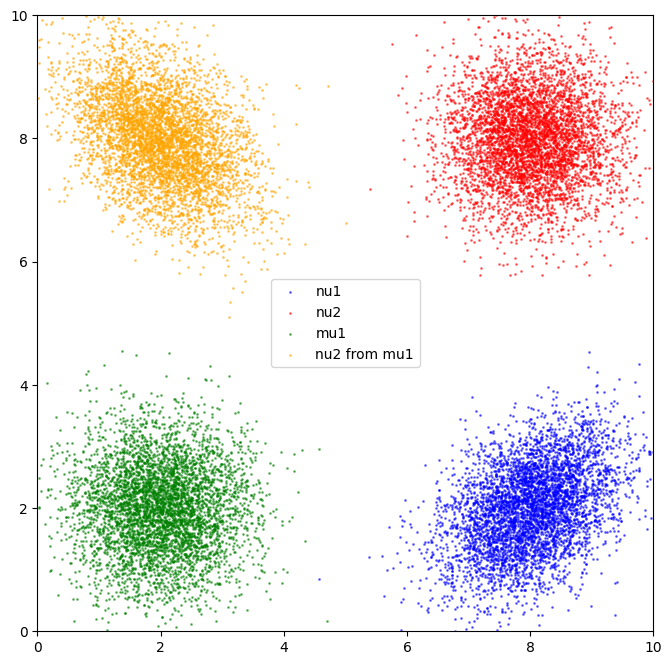

In [28]:
# test with samples from normal
n_samples_nu_1 = 5000
n_samples_nu_2 = 5000
n_samples_mu_1 = 5000

mean_nu1 = np.array([8, 2])
sigma_nu1 = np.array([[0.5, 0.2], [0.2, 0.5]])

mean_nu2 = np.array([8, 8])
sigma_nu2 = np.array([[0.5, 0.0], [0.0, 0.5]])

mean_mu1 = np.array([2, 2])
sigma_mu1 = np.array([[0.5, 0.0], [0.0, 0.5]])

# sample n_samples from nu_1, mu_1 and nu_2
nu1_samples = np.random.multivariate_normal(mean_nu1, sigma_nu1, size=n_samples_nu_1)
nu2_samples = np.random.multivariate_normal(mean_nu2, sigma_nu2, size=n_samples_nu_2)
mu1_samples = np.random.multivariate_normal(mean_mu1, sigma_mu1, size=n_samples_mu_1)

# obtain logmap from nu1 to nu2 and from nu1 to mu1
nu1_measure = EmpiricalMeasure(nu1_samples, np.ones(n_samples_nu_1) / n_samples_nu_1)
nu2_measure = EmpiricalMeasure(nu2_samples, np.ones(n_samples_nu_2) / n_samples_nu_2)
mu1_measure = EmpiricalMeasure(mu1_samples, np.ones(n_samples_mu_1) / n_samples_mu_1)

tangent_nu1_nu2 = wasserstein_logmap(nu1_measure, nu2_measure)
tangent_nu1_mu1 = wasserstein_logmap(nu1_measure, mu1_measure)

# parallel transport tangent_nu1_nu2 from nu1 to mu1
tangent_nu2_mu1 = parallel_transport_wasserstein(tangent_nu1_nu2, nu1_measure, mu1_measure, n=10)
# compute the exponential map of the transported tangent at mu1
nu2_from_mu1 = wasserstein_expmap(mu1_measure, tangent_nu2_mu1)

# visualize by plotting and color-coding the measures (no tangents)
plt.figure(figsize=(8, 8))
plt.scatter(nu1_measure.locs[:, 0], nu1_measure.locs[:, 1], color='blue', alpha=0.5, label='nu1', s=1)
plt.scatter(nu2_measure.locs[:, 0], nu2_measure.locs[:, 1], color='red', alpha=0.5, label='nu2', s=1)
plt.scatter(mu1_measure.locs[:, 0], mu1_measure.locs[:, 1], color='green', alpha=0.5, label='mu1', s=1)
plt.scatter(nu2_from_mu1.locs[:, 0], nu2_from_mu1.locs[:, 1], color='orange', alpha=0.5, label='nu2 from mu1', s=1)
# set axis limits for better visualization
plt.xlim(0, 10)
plt.ylim(0, 10)
# set aspect ratio to equal for proper distance visualization
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()



In [12]:
print(tangent_nu1_mu1.locs_src[0:15])
print(mu1_measure.locs[0:15])

[[ 8.72748917  2.52499368]
 [ 6.37580235  0.45202306]
 [ 6.79236768  2.51273868]
 [ 8.12212261  2.11201791]
 [10.01014778  2.9574175 ]
 [ 7.87389789  0.83592028]
 [ 8.30459922  1.12000505]
 [ 6.53779808  2.55135464]
 [ 7.17445074  2.85465856]
 [ 6.3857523   2.17856825]
 [ 7.74887875  2.277183  ]
 [ 8.56020153  2.42274745]
 [ 8.34781706  2.36527641]
 [ 8.23305278  2.80913343]
 [ 8.12831328  1.87950012]]
[[1.35266494 1.6987689 ]
 [2.00493013 2.48644828]
 [2.9956508  2.39357299]
 [2.68201909 2.30885046]
 [2.30303482 2.16720793]
 [1.8864923  2.49163261]
 [2.28977974 2.32137322]
 [1.56639603 2.28612148]
 [2.95882985 2.92537747]
 [1.29264305 2.81162208]
 [2.10578084 1.58053968]
 [1.49433615 0.58579194]
 [2.5248867  2.09169871]
 [2.77668778 0.91523914]
 [1.44059904 0.63774064]]


In [5]:
locs = np.array([[0.0], [1.0]])
weights = np.array([0.5, 0.5])
base = EmpiricalMeasure(locs, weights)

vels = np.array([[0.5], [-0.5]])
tangent = W2EuclideanTangent(locs_src = locs, vels = vels)

moved = wasserstein_expmap(base, tangent)
logmap = wasserstein_logmap(moved, base)


print("Base locations:", base.locs)
print("Base weights:", base.weights)
print("Moved locations:", moved.locs)
print("Moved weights:", moved.weights)
print("Logmap vels:", logmap.vels)
print("Logmap coupling:", logmap.coupling)


Base locations: [[0.]
 [1.]]
Base weights: [0.5 0.5]
Moved locations: [[0.5]]
Moved weights: [1.]
Logmap vels: None
Logmap coupling: [[0.5 0.5]]


Tangent locs_src: [[0.5]]
Tangent vels: None
Tangent locs_dst: [[0.]
 [1.]]
Tangent coupling: [[0.5 0.5]]


(-0.1, 1.5)

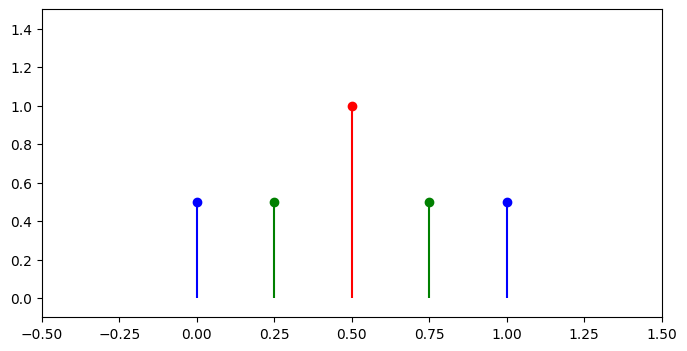

In [79]:
# compute the logarithmic map of dst at src
src_locs = np.array([[0.5]])
src_weights = np.array([1.0])

dst_locs = np.array([[0.0], [1.0]])
dst_weights = np.array([0.5, 0.5])

src = EmpiricalMeasure(src_locs, src_weights)
dst = EmpiricalMeasure(dst_locs, dst_weights)
tangent = wasserstein_logmap(src, dst)

tan_halfway = interp_tan_coupling(tangent, t_0=0.0, t_1=0.5)
interp = wasserstein_expmap(src, tan_halfway)
interp_locs = interp.locs
interp_weights = interp.weights

print("Tangent locs_src:", tangent.locs_src)
print("Tangent vels:", tangent.vels)
print("Tangent locs_dst:", tangent.locs_dst)
print("Tangent coupling:", tangent.coupling)

# plot empirical measures as dirac deltas
plt.figure(figsize=(8, 4))
plt.stem(base.locs.flatten(), base.weights, linefmt='b-', markerfmt='bo', basefmt=' ', label='Src Measure')
plt.stem(interp_locs.flatten(), interp_weights, linefmt='g-', markerfmt='go', basefmt=' ', label='Interpolated Measure')
plt.stem(moved.locs.flatten(), moved.weights, linefmt='r-', markerfmt='ro', basefmt=' ', label='Target Measure')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.1, 1.5)